In [133]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import io
import os

In [134]:
hdr_path = r"Obrazy lotnicze/221000_Odra_HS_Blok_A_015_VS_join_atm.hdr"

if not os.path.exists(hdr_path):
    print(f"BŁĄD: Nie znaleziono pliku {hdr_path}. Sprawdź ścieżkę.")
else:
    print("Wczytywanie kostki danych...")
    img = io.envi.open(hdr_path)
    
    wavelengths = img.metadata.get('wavelength')
    if wavelengths is None:
        print("BŁĄD: Brak informacji o długościach fal w pliku .hdr.")
    else:
        wl_list = [float(x) for x in wavelengths]

        def get_band_index(target_wl, wl_list):
            return np.argmin(np.abs(np.array(wl_list) - target_wl))

        nir_wl = 842   # Bliska Podczerwień (Vegetation, Water edge)
        red_wl = 665   # Czerwień (Chlorophyll absorption)
        green_wl = 560 # Zieleń (Vegetation reflection)

        idx_nir = get_band_index(nir_wl, wl_list)
        idx_red = get_band_index(red_wl, wl_list)
        idx_green = get_band_index(green_wl, wl_list)

        print(f"Wybrane pasma dla FCC:")
        print(f"  R (NIR):   Band {idx_nir+1} ({wl_list[idx_nir]:.2f} nm)")
        print(f"  G (Red):   Band {idx_red+1} ({wl_list[idx_red]:.2f} nm)")
        print(f"  B (Green): Band {idx_green+1} ({wl_list[idx_green]:.2f} nm)")




Wczytywanie kostki danych...
Wybrane pasma dla FCC:
  R (NIR):   Band 135 (842.47 nm)
  G (Red):   Band 79 (663.46 nm)
  B (Green): Band 47 (561.17 nm)


In [135]:
idx_re = get_band_index(705, wl_list)
idx_red = get_band_index(665, wl_list)

band_re = img.read_band(idx_re).astype(np.float32)
band_red = img.read_band(idx_red).astype(np.float32)

chl_a = band_re / (band_red + 1e-6)

idx_green = get_band_index(560, wl_list)
band_green = img.read_band(idx_green).astype(np.float32)

doc = band_green / (band_red + 1e-6)

print("Wskaźniki chl_a i doc zostały obliczone.")

Wskaźniki chl_a i doc zostały obliczone.


In [136]:
        fcc_data = img.read_bands([idx_nir, idx_red, idx_green]).astype(np.float32)

        fcc_visual = np.zeros_like(fcc_data)
        for i in range(3):
            band = fcc_data[:,:,i]
            p2, p98 = np.nanpercentile(band, [2, 98])
            fcc_visual[:,:,i] = np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)

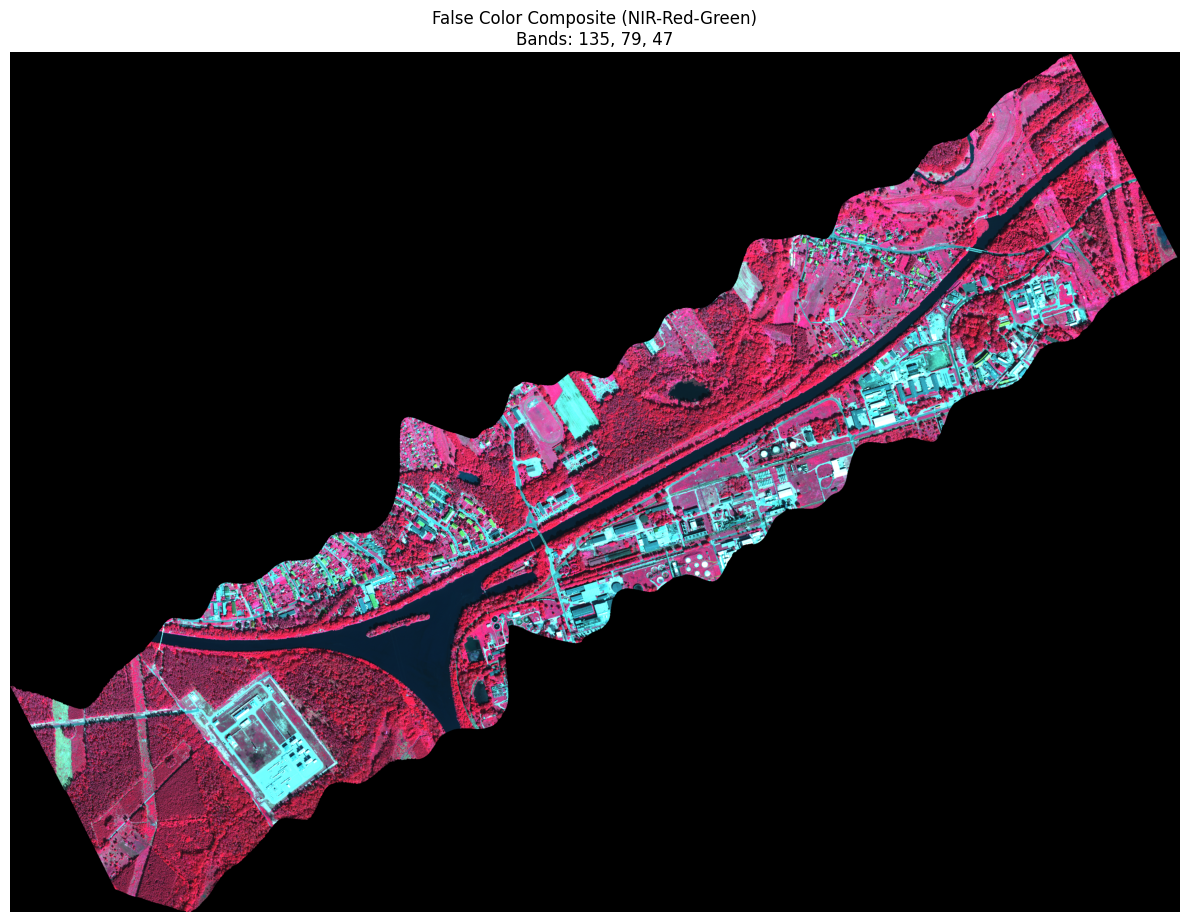

In [137]:
        plt.figure(figsize=(12, 10))
        plt.imshow(fcc_visual)
        plt.title(f"False Color Composite (NIR-Red-Green)\nBands: {idx_nir+1}, {idx_red+1}, {idx_green+1}")
        plt.axis('off') 
        plt.tight_layout()
        plt.show()

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from spectral import io
from pathlib import Path

data_folder = Path(r"E:\Remote_sensing\eolabs-main\lab_5\Obrazy lotnicze")

hdr_files = list(data_folder.glob("*.hdr"))[:3] 

print(f"Wybrane pliki do analizy: {[f.name for f in hdr_files]}")

def get_b(target_wl, wl_list):
    return np.argmin(np.abs(np.array(wl_list) - target_wl))

Wybrane pliki do analizy: ['221000_Odra_HS_Blok_A_008_VS_join_atm.hdr', '221000_Odra_HS_Blok_A_013_VS_join_atm.hdr', '221000_Odra_HS_Blok_A_015_VS_join_atm.hdr']


In [139]:
all_results = {}

for hdr_path in hdr_files:
    print(f"Przetwarzanie: {hdr_path.name}...")
    img = io.envi.open(str(hdr_path))
    wl_list = [float(x) for x in img.metadata['wavelength']]
    
    idx_green = get_b(560, wl_list)
    idx_red   = get_b(665, wl_list)
    idx_re    = get_b(705, wl_list)
    idx_682   = get_b(682, wl_list) 
    idx_700   = get_b(700, wl_list) 
    idx_nir   = get_b(842, wl_list)
    
    bands = [idx_green, idx_red, idx_re, idx_682, idx_700, idx_nir]
    cube = img.read_bands(bands).astype(np.float32)
    
    g, r, re, r682, r700, nir = [cube[:,:,i] for i in range(6)]
    
    ndwi = (g - nir) / (g + nir + 1e-6)
    water_mask = ndwi > 0.01
    
    results = {
        'Chl-a': np.where(water_mask, re / (r + 1e-6), np.nan),
        'DOC': np.where(water_mask, g / (r + 1e-6), np.nan),
        'Turbidity': np.where(water_mask, r, np.nan),
        'GAI': np.where(water_mask, r682 - (r + ((r700 - r) / (700-665)) * (682-665)), np.nan)
    }
    
    all_results[hdr_path.stem] = results

print("Wszystkie zdjęcia zostały przeliczone.")

Przetwarzanie: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr...
Przetwarzanie: 221000_Odra_HS_Blok_A_013_VS_join_atm.hdr...
Przetwarzanie: 221000_Odra_HS_Blok_A_015_VS_join_atm.hdr...
Wszystkie zdjęcia zostały przeliczone.



 WYNIKI DLA: 221000_Odra_HS_Blok_A_008_VS_join_atm


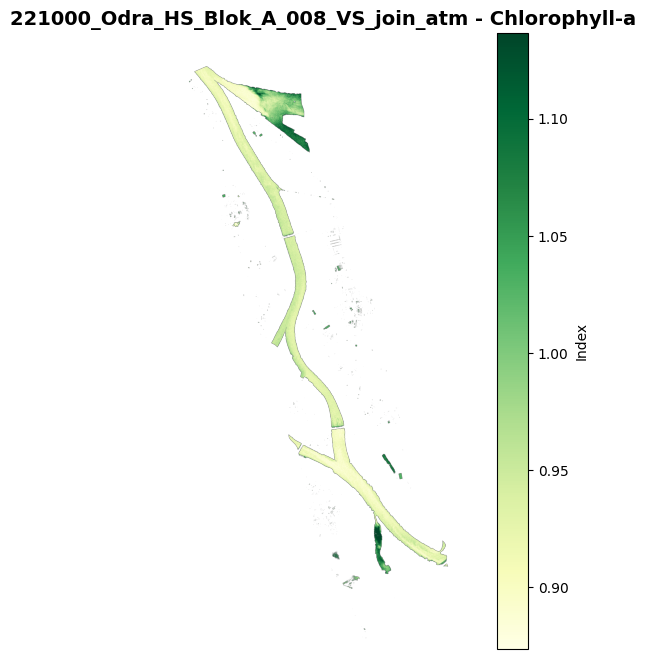

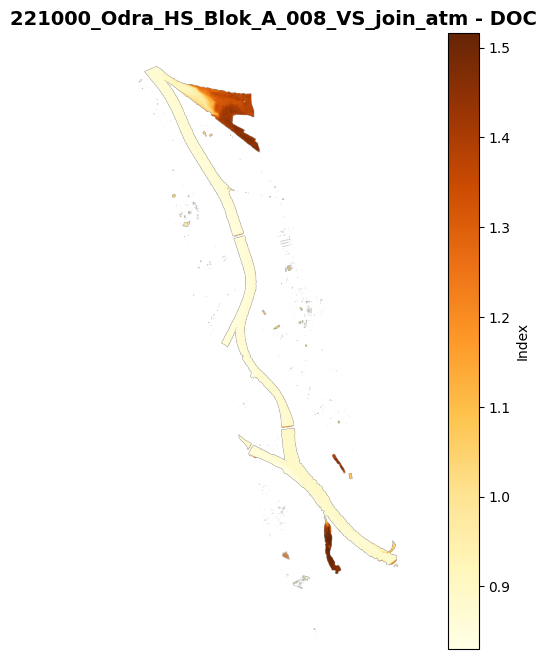

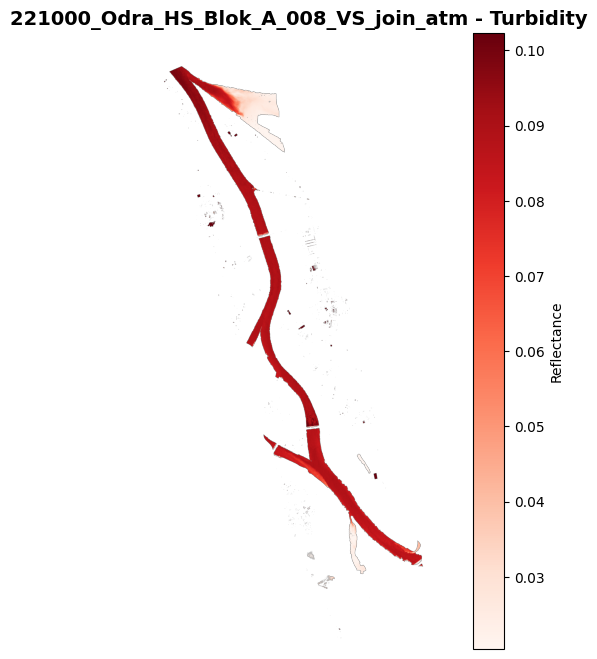

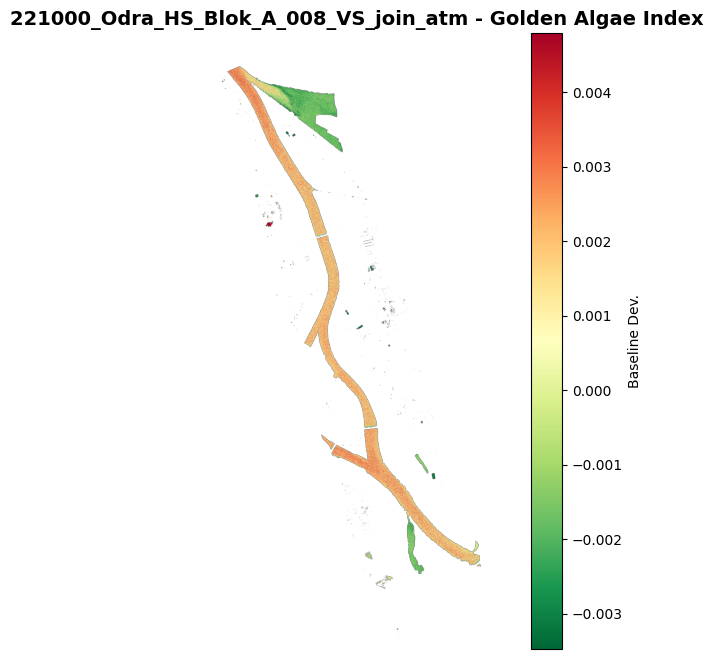


 WYNIKI DLA: 221000_Odra_HS_Blok_A_013_VS_join_atm


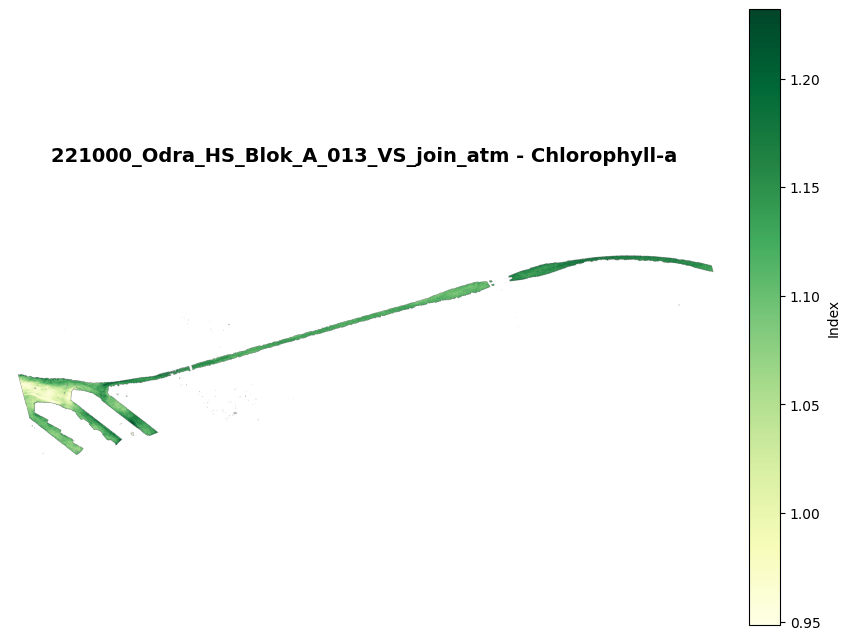

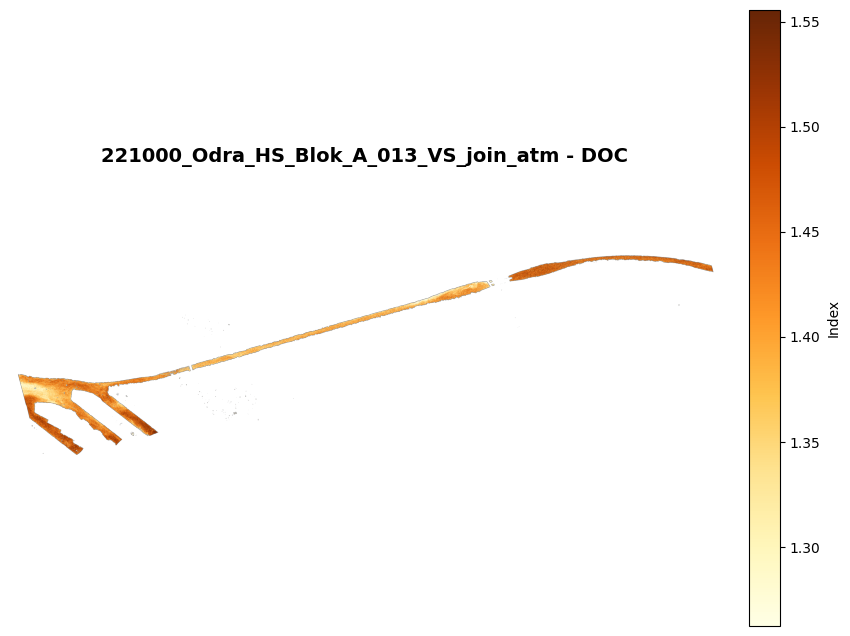

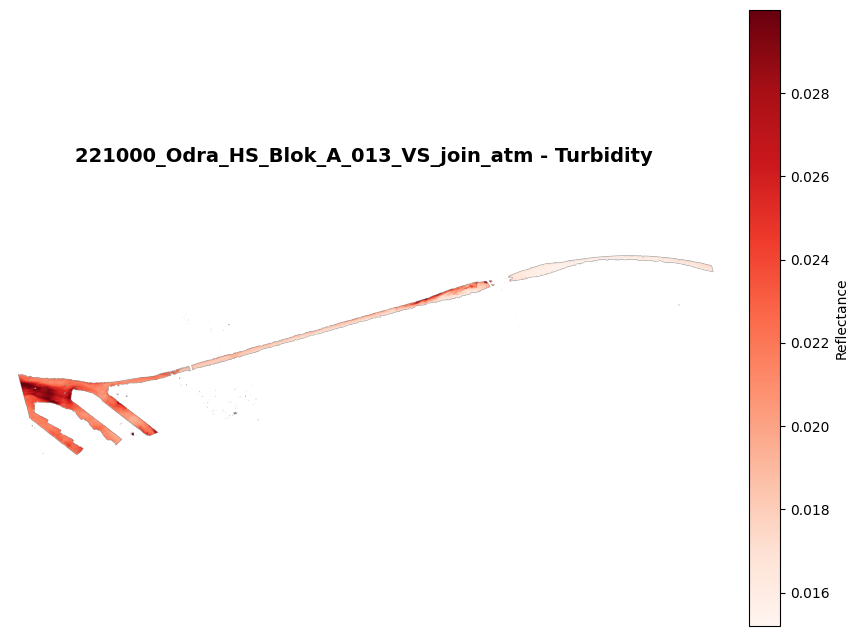

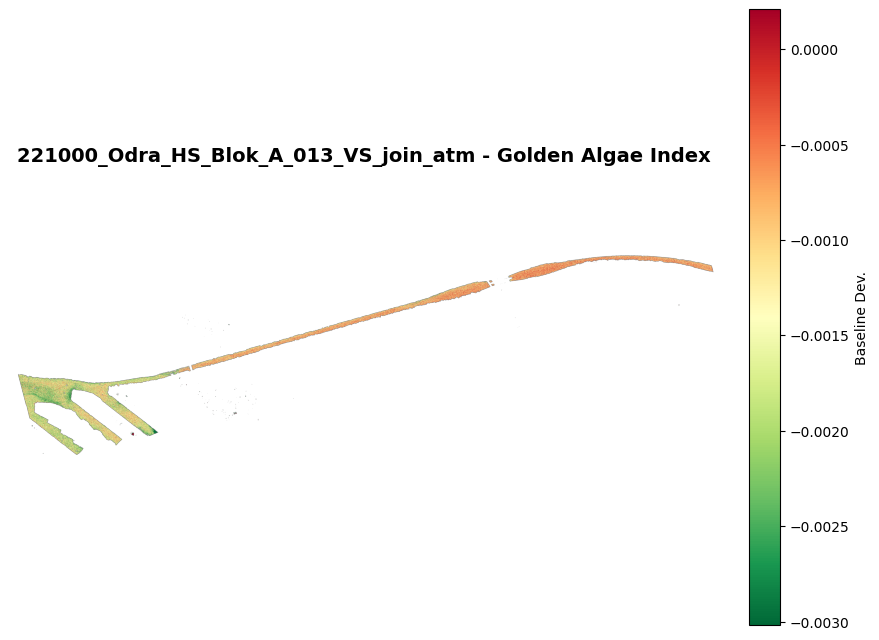


 WYNIKI DLA: 221000_Odra_HS_Blok_A_015_VS_join_atm


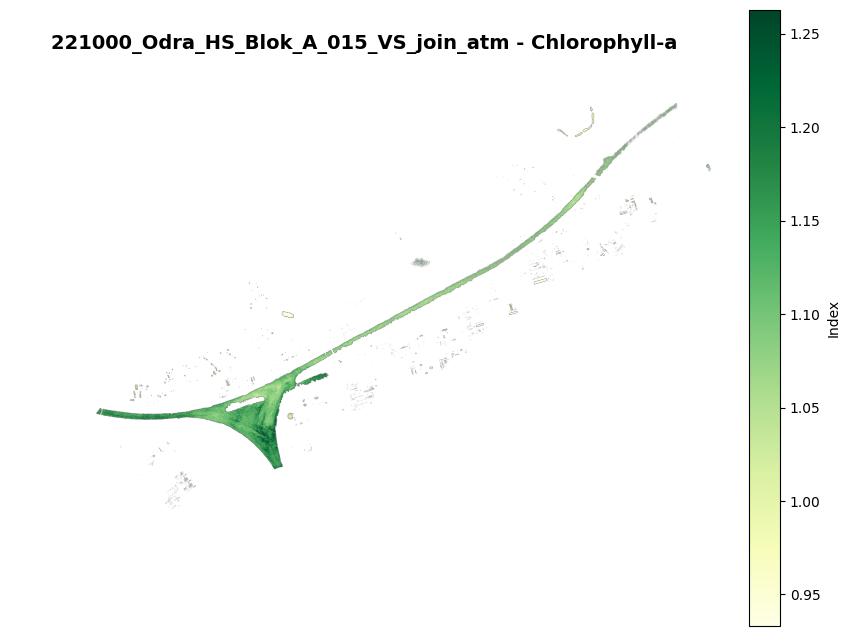

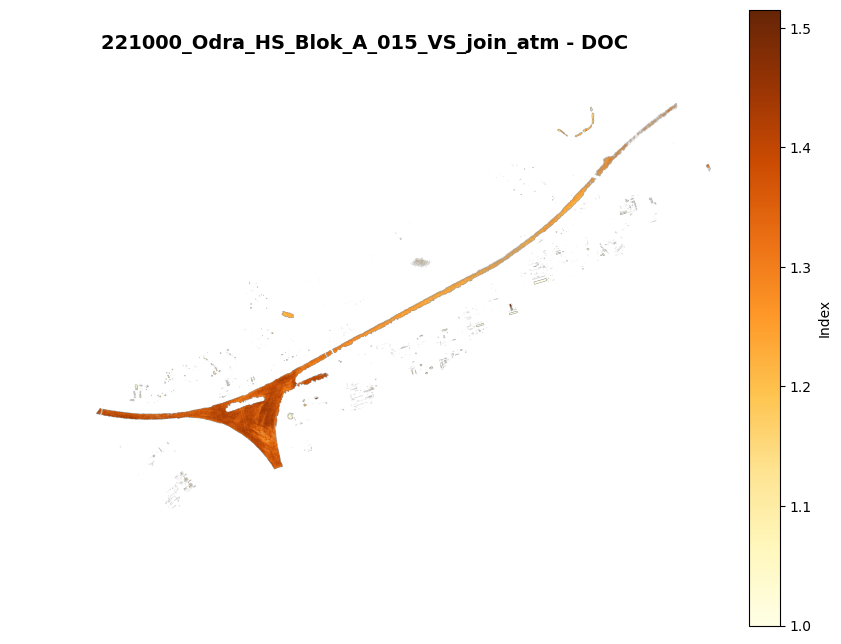

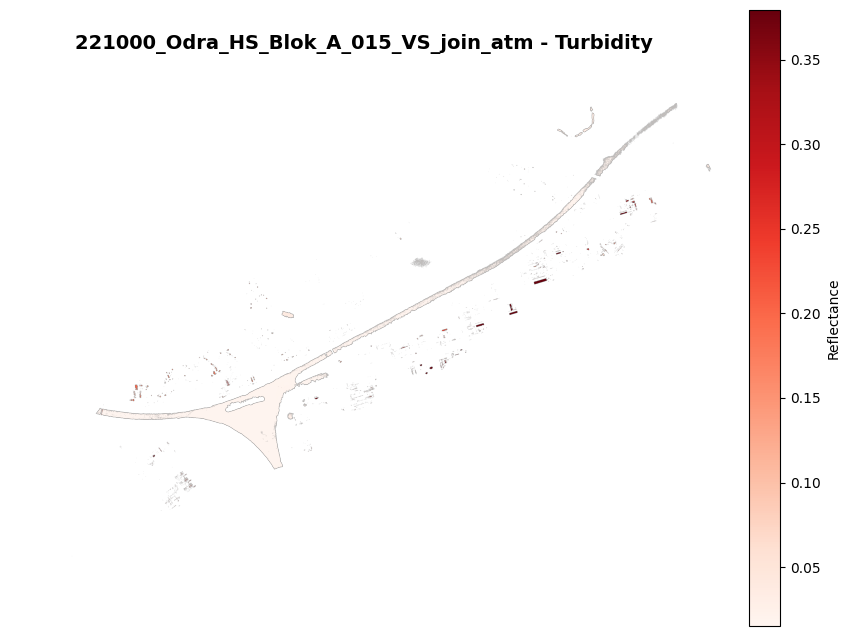

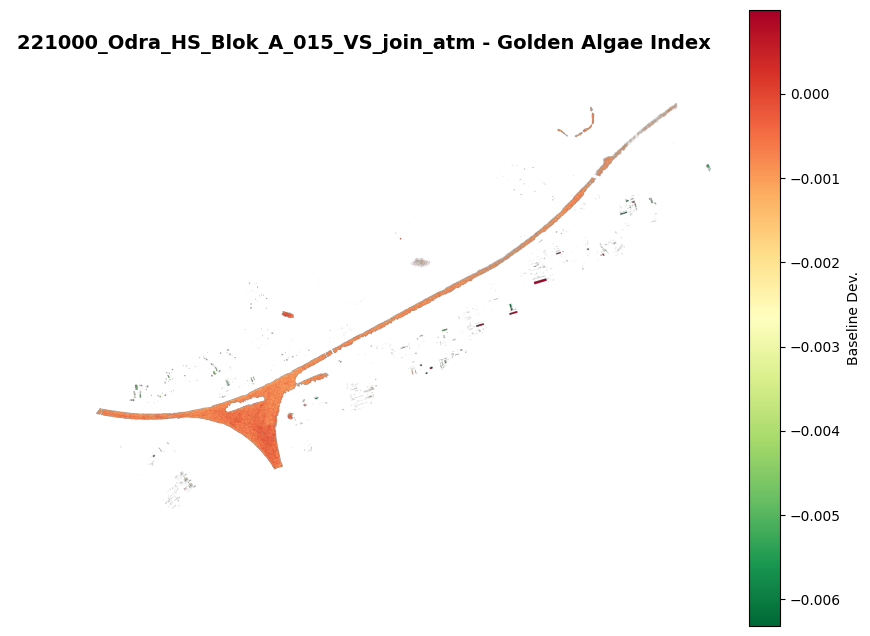

In [140]:
def show_single_plot(data, title, cmap, label):
    plt.figure(figsize=(10, 8))
    valid = data[~np.isnan(data)]
    if len(valid) > 0:
        vmin, vmax = np.percentile(valid, [2, 98])
    else:
        vmin, vmax = 0, 1
        
    plt.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label=label, fraction=0.046, pad=0.04)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

for name, res in all_results.items():
    print(f"\n" + "="*50)
    print(f" WYNIKI DLA: {name}")
    print("="*50)
    
    show_single_plot(res['Chl-a'], f"{name} - Chlorophyll-a", "YlGn", "Index")
    show_single_plot(res['DOC'], f"{name} - DOC", "YlOrBr", "Index")
    show_single_plot(res['Turbidity'], f"{name} - Turbidity", "Reds", "Reflectance")
    show_single_plot(res['GAI'], f"{name} - Golden Algae Index", "RdYlGn_r", "Baseline Dev.")

Przeszukiwanie folderu: E:\Remote_sensing\eolabs-main\lab_5\sentinel dla daty 2025-06-15...
  Znaleziono B02: 2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L1C_B02_(Raw).tiff
  Znaleziono B03: 2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L1C_B03_(Raw).tiff
  Znaleziono B04: 2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L1C_B04_(Raw).tiff
  Znaleziono B05: 2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L1C_B05_(Raw).tiff
  Znaleziono B08: 2025-06-15-00_00_2025-06-15-23_59_Sentinel-2_L1C_B08_(Raw).tiff
  OSTRZEŻENIE: Nie znaleziono pasma B11 dla daty 2025-06-15.

Wczytywanie referencyjnego pasma 10m (B03)...
Wczytywanie i skalowanie pasma B02 do siatki B03 (10m)...
Wczytywanie i skalowanie pasma B04 do siatki B03 (10m)...
Wczytywanie i skalowanie pasma B05 do siatki B03 (10m)...
Wczytywanie i skalowanie pasma B08 do siatki B03 (10m)...

Udało się wczytać 5 pasm Sentinel-2 (B03, B02, B04, B05, B08) do wspólnej siatki 10m.

Stosowanie liniowego stretchu kontrastu (2-98%): v_min=0.0000, v_max=0

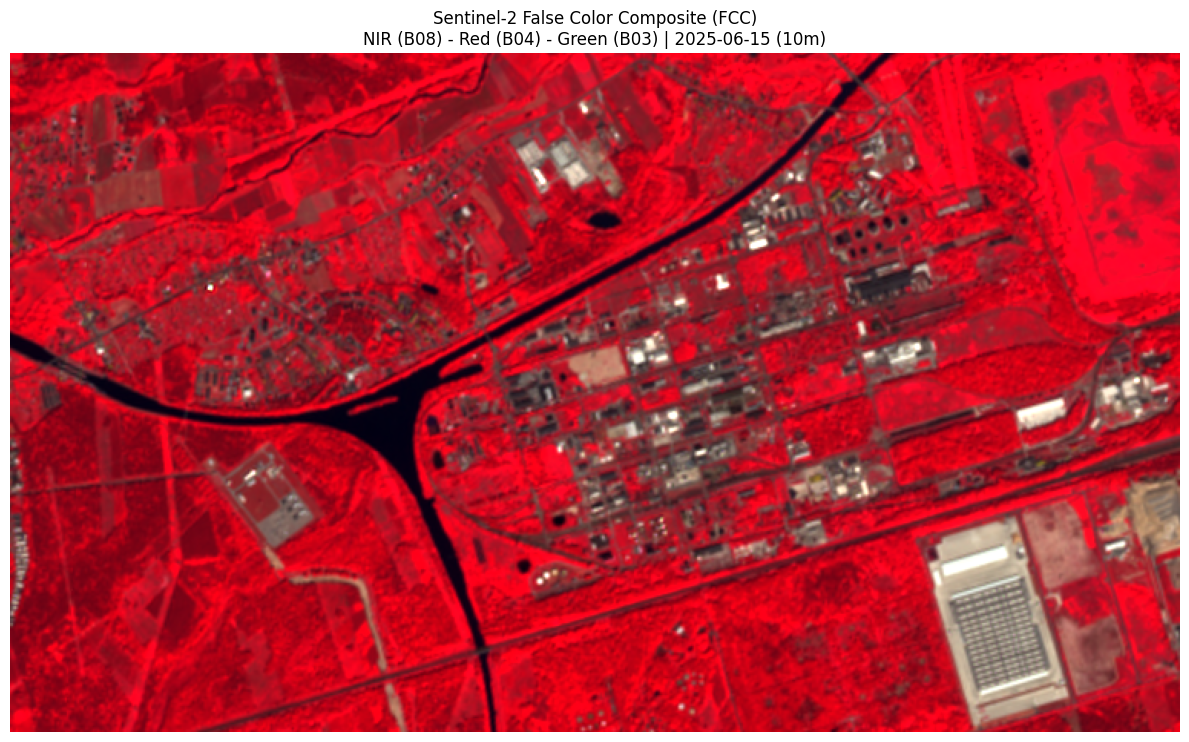

In [141]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sentinel_dir = Path(r"E:\Remote_sensing\eolabs-main\lab_5\sentinel")
date_str = "2025-06-15" 

bands_to_load = ['B02', 'B03', 'B04', 'B05', 'B08', 'B11']

sentinel_bands = {}

def load_and_resample_band(path, target_shape=None):
    """
    Wczytuje pasmo. Jeśli podano target_shape, skaluje (resample) dane do tych wymiarów.
    GeoTIFFy są wczytywane z automatyczną konwersją na float i obsługą NaN.
    """
    with rasterio.open(path) as src:
        if target_shape:
            data = src.read(
                1,
                out_shape=(src.count, target_shape[0], target_shape[1]),
                resampling=Resampling.bilinear
            ).astype(np.float32) / 10000.0 
        else:
            data = src.read(1).astype(np.float32) / 10000.0 

        data = np.clip(np.nan_to_num(data, nan=0.0), 0.0, 1.0)
        return data

print(f"Przeszukiwanie folderu: {sentinel_dir} dla daty {date_str}...")

potential_files = list(sentinel_dir.rglob("*.tiff")) + list(sentinel_dir.rglob("*.jp2"))

ref_shape = None

band_paths = {}

for band in bands_to_load:
    search_pattern = f"*{band}*"
    band_file = sentinel_dir.rglob(search_pattern)
    
    band_file = next(band_file, None)
    
    if band_file:
        print(f"  Znaleziono {band}: {band_file.name}")
        band_paths[band] = band_file
    else:
        print(f"  OSTRZEŻENIE: Nie znaleziono pasma {band} dla daty {date_str}.")

ref_band = 'B03'
if ref_band in band_paths:
    print(f"\nWczytywanie referencyjnego pasma 10m ({ref_band})...")
    sentinel_bands[ref_band] = load_and_resample_band(band_paths[ref_band])
    ref_shape = sentinel_bands[ref_band].shape
else:
    print(f"\nBŁĄD KRYTYCZNY: Nie znaleziono pasma referencyjnego {ref_band} do ustalenia siatki 10m.")

for band, path in band_paths.items():
    if band != ref_band and ref_shape:
        print(f"Wczytywanie i skalowanie pasma {band} do siatki {ref_band} (10m)...")
        sentinel_bands[band] = load_and_resample_band(path, target_shape=ref_shape)

print(f"\nUdało się wczytać {len(sentinel_bands)} pasm Sentinel-2 ({', '.join(sentinel_bands.keys())}) do wspólnej siatki 10m.")

if all(b in sentinel_bands for b in ['B08', 'B04', 'B03']):
    fcc_stack = np.dstack((sentinel_bands['B08'], sentinel_bands['B04'], sentinel_bands['B03']))

    v_min = np.nanpercentile(fcc_stack, 2)
    v_max = np.nanpercentile(fcc_stack, 98)
    
    print(f"\nStosowanie liniowego stretchu kontrastu (2-98%): v_min={v_min:.4f}, v_max={v_max:.4f}")
    fcc_visual = np.clip((fcc_stack - v_min) / (v_max - v_min), 0.0, 1.0)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(fcc_visual)
    plt.title(f"Sentinel-2 False Color Composite (FCC)\nNIR (B08) - Red (B04) - Green (B03) | {date_str} (10m)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("\nBŁĄD: Nie można stworzyć FCC. Brakuje pasm B08, B04 lub B03 w Twoim folderze.")

In [142]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt

def load_s2_band(band_name, target_shape=None):
    path = next(sentinel_dir.rglob(f"*{band_name}*.tiff"))
    with rasterio.open(path) as src:
        if target_shape:
            data = src.read(1, out_shape=target_shape, resampling=Resampling.bilinear)
        else:
            data = src.read(1)
        return data.astype(np.float32)

s2_b03 = load_s2_band("B03") 
s2_b04 = load_s2_band("B04") 
s2_b08 = load_s2_band("B08") 

s2_b05 = load_s2_band("B05", target_shape=s2_b03.shape) 

s2_ndwi = (s2_b03 - s2_b08) / (s2_b03 + s2_b08 + 1e-6)
s2_water_mask = s2_ndwi > 0.01 

print("Pasma Sentinel-2 wczytane i maska wody przygotowana.")

Pasma Sentinel-2 wczytane i maska wody przygotowana.


In [143]:
s2_chl_a = np.where(s2_water_mask, s2_b05 / (s2_b04 + 1e-6), np.nan)

s2_doc = np.where(s2_water_mask, s2_b03 / (s2_b04 + 1e-6), np.nan)

s2_turbidity = np.where(s2_water_mask, s2_b04, np.nan)

s2_gai = np.where(s2_water_mask, s2_b04 - ((s2_b03 + s2_b05) / 2), np.nan)

print("Wskaźniki satelitarne obliczone.")

Wskaźniki satelitarne obliczone.


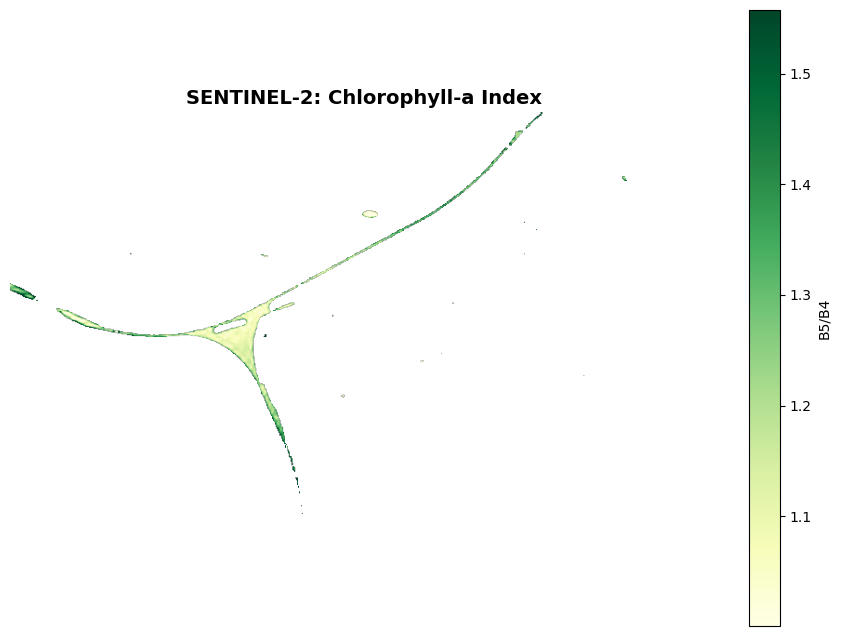

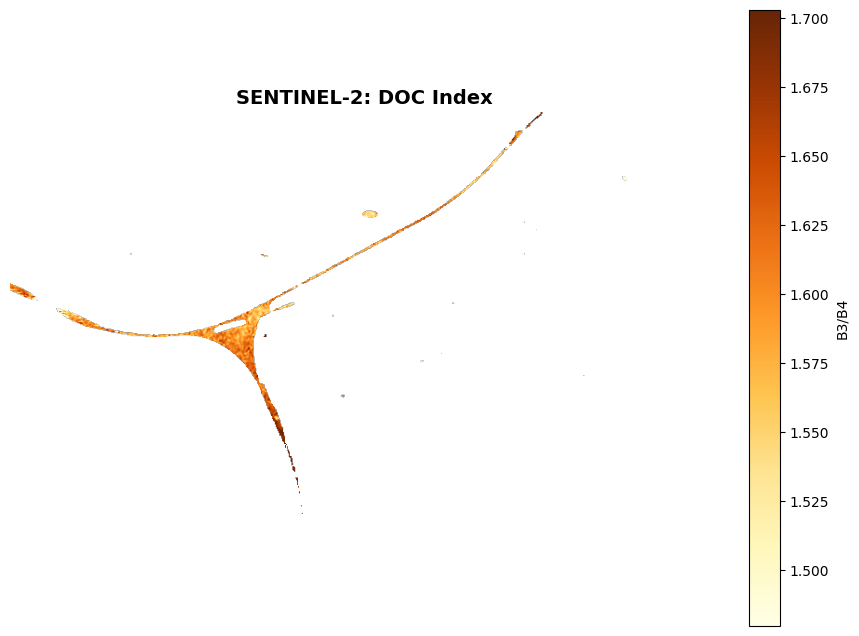

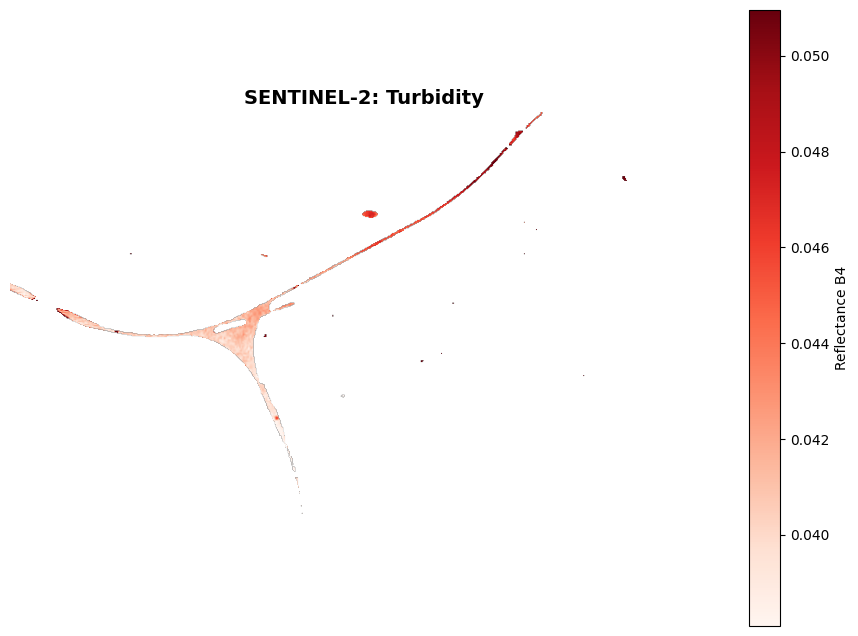

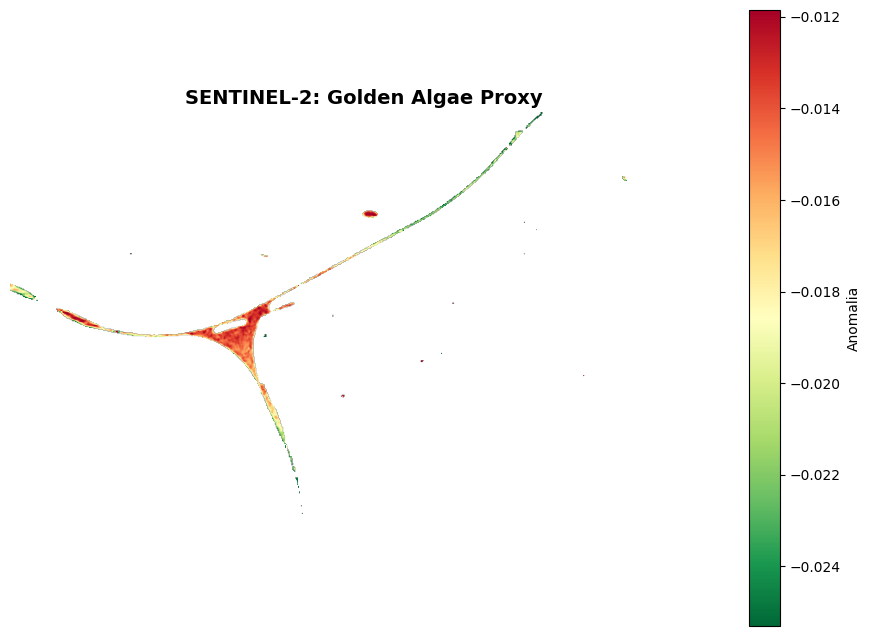

In [144]:
def plot_s2_index(data, title, cmap, label):
    plt.figure(figsize=(10, 8))
    valid = data[~np.isnan(data)]
    if len(valid) > 0:
        vmin, vmax = np.percentile(valid, [2, 98])
    else:
        vmin, vmax = 0, 1
        
    plt.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label=label, fraction=0.046, pad=0.04)
    plt.title(f"SENTINEL-2: {title}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

plot_s2_index(s2_chl_a, "Chlorophyll-a Index", "YlGn", "B5/B4")
plot_s2_index(s2_doc, "DOC Index", "YlOrBr", "B3/B4")
plot_s2_index(s2_turbidity, "Turbidity", "Reds", "Reflectance B4")
plot_s2_index(s2_gai, "Golden Algae Proxy", "RdYlGn_r", "Anomalia")

In [145]:
import rasterio
import numpy as np

def get_kozle_band(band_name):
    """
    Wczytuje konkretne pasmo z wielowarstwowego pliku GeoTIFF.
    """
    path = r"E:\Remote_sensing\eolabs-main\lab_5\sentinel\S2_Export_2025-06-15.tif"
    
    # Mapowanie nazw pasm na numery warstw w pliku TIFF
    # Uwaga: Kolejność zależy od tego, jak wyeksportowano plik. 
    # Standardowo dla S2: B1=1, B2=2, ..., B8=8, B11=11, B12=12
    band_map = {
        "B01": 1, "B02": 2, "B03": 3, "B04": 4,
        "B05": 5, "B06": 6, "B07": 7, "B08": 8,
        "B8A": 9, "B09": 10, "B11": 11, "B12": 12
    }
    
    if band_name not in band_map:
        raise ValueError(f"Nieznane pasmo: {band_name}. Wybierz np. 'B08'")
    
    band_index = band_map[band_name]
    
    with rasterio.open(path) as src:
        # Sprawdzamy czy plik ma wystarczającą liczbę warstw
        if src.count < band_index:
            raise IndexError(f"Plik ma tylko {src.count} warstw, nie można pobrać warstwy {band_index}")
            
        # Wczytujemy wybraną warstwę
        band = src.read(band_index).astype('float32')
        
        # Opcjonalnie: zamiana wartości 0 (brak danych) na NaN
        band[band == 0] = np.nan
        return band

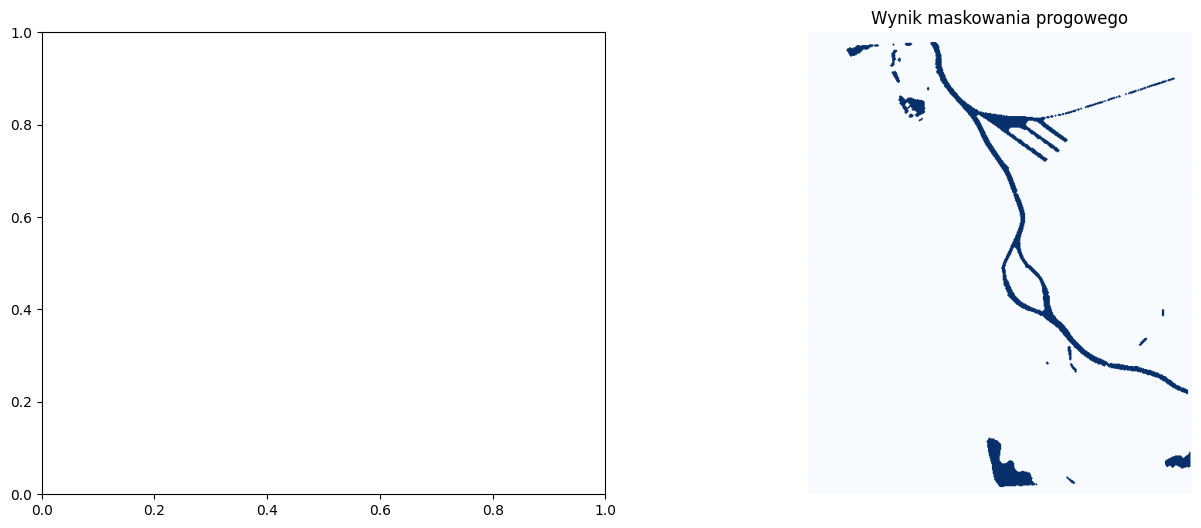

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

nir = get_kozle_band("B08")

manual_threshold = np.nanpercentile(nir, 4) 

water_mask_threshold = nir < manual_threshold

water_mask_threshold = ndimage.binary_opening(water_mask_threshold, iterations=1)
water_mask_threshold = ndimage.binary_closing(water_mask_threshold, iterations=2)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].hist(nir.flatten(), bins=100, range=(0, 2000), color='skyblue', edgecolor='black')
ax[0].axvline(manual_threshold, color='red', linestyle='dashed', linewidth=2)
ax[0].set_title(f"Histogram NIR (Próg: {manual_threshold:.0f})")

ax[1].imshow(water_mask_threshold, cmap='Blues')
ax[1].set_title("Wynik maskowania progowego")
ax[1].axis('off')

plt.show()

In [ ]:

green = get_kozle_band("B03")
red   = get_kozle_band("B04")
re    = get_kozle_band("B05")

s2_chl_a_final = np.where(water_mask_threshold, re / (red + 1e-6), np.nan)

s2_turb_final = np.where(water_mask_threshold, red, np.nan)

s2_gai_final = np.where(water_mask_threshold, red - ((green + re) / 2), np.nan)

print(f"Przeliczono wskaźniki przy użyciu progu NIR: {manual_threshold}")

Przeliczono wskaźniki przy użyciu progu NIR: 0.0965319350361824


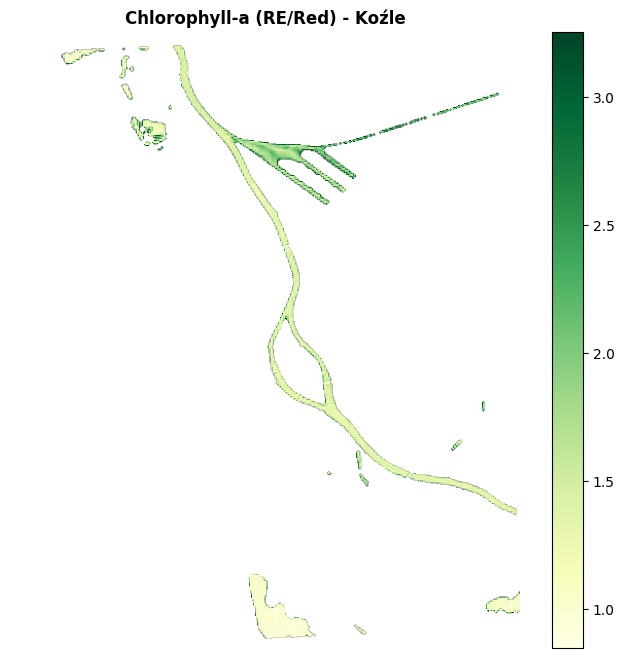

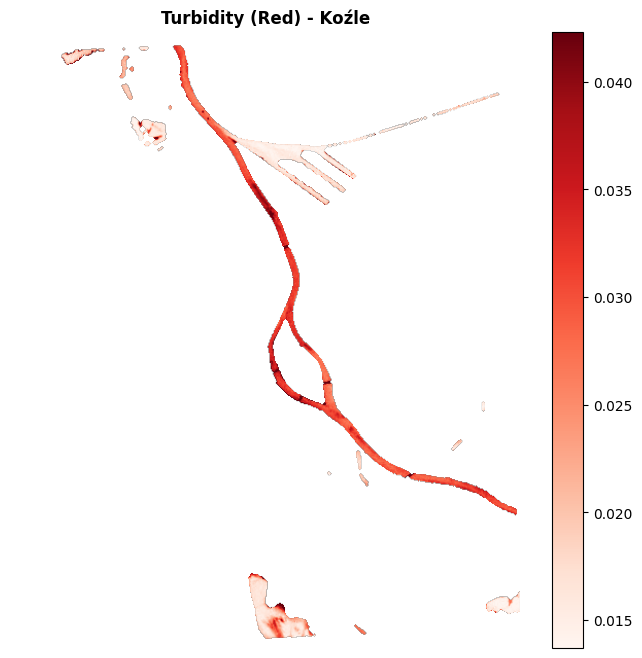

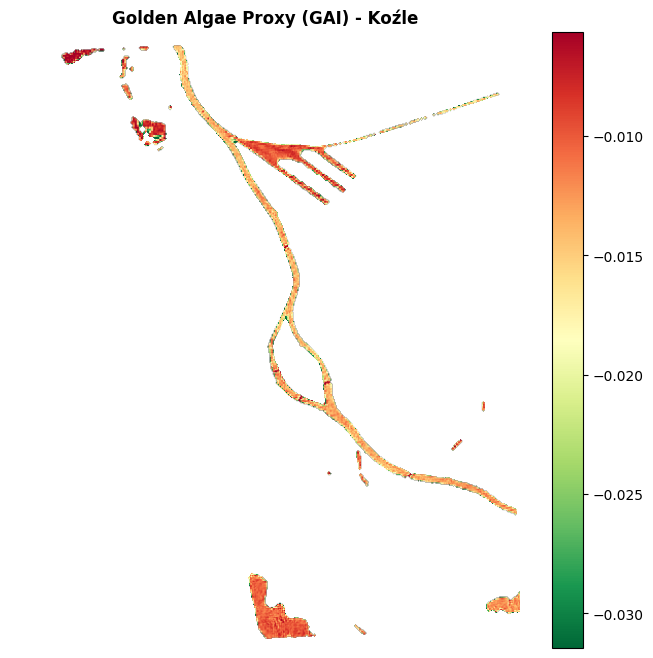

In [ ]:
def plot_final_kozle(data, title, cmap):
    plt.figure(figsize=(10, 8))
    valid = data[~np.isnan(data)]
    if len(valid) > 0:
        vmin, vmax = np.percentile(valid, [2, 98])
    else:
        vmin, vmax = 0, 1
        
    plt.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title, fontweight='bold')
    plt.axis('off')
    plt.show()

plot_final_kozle(s2_chl_a_final, "Chlorophyll-a (RE/Red) - Koźle", "YlGn")
plot_final_kozle(s2_turb_final, "Turbidity (Red) - Koźle", "Reds")
plot_final_kozle(s2_gai_final, "Golden Algae Proxy (GAI) - Koźle", "RdYlGn_r")

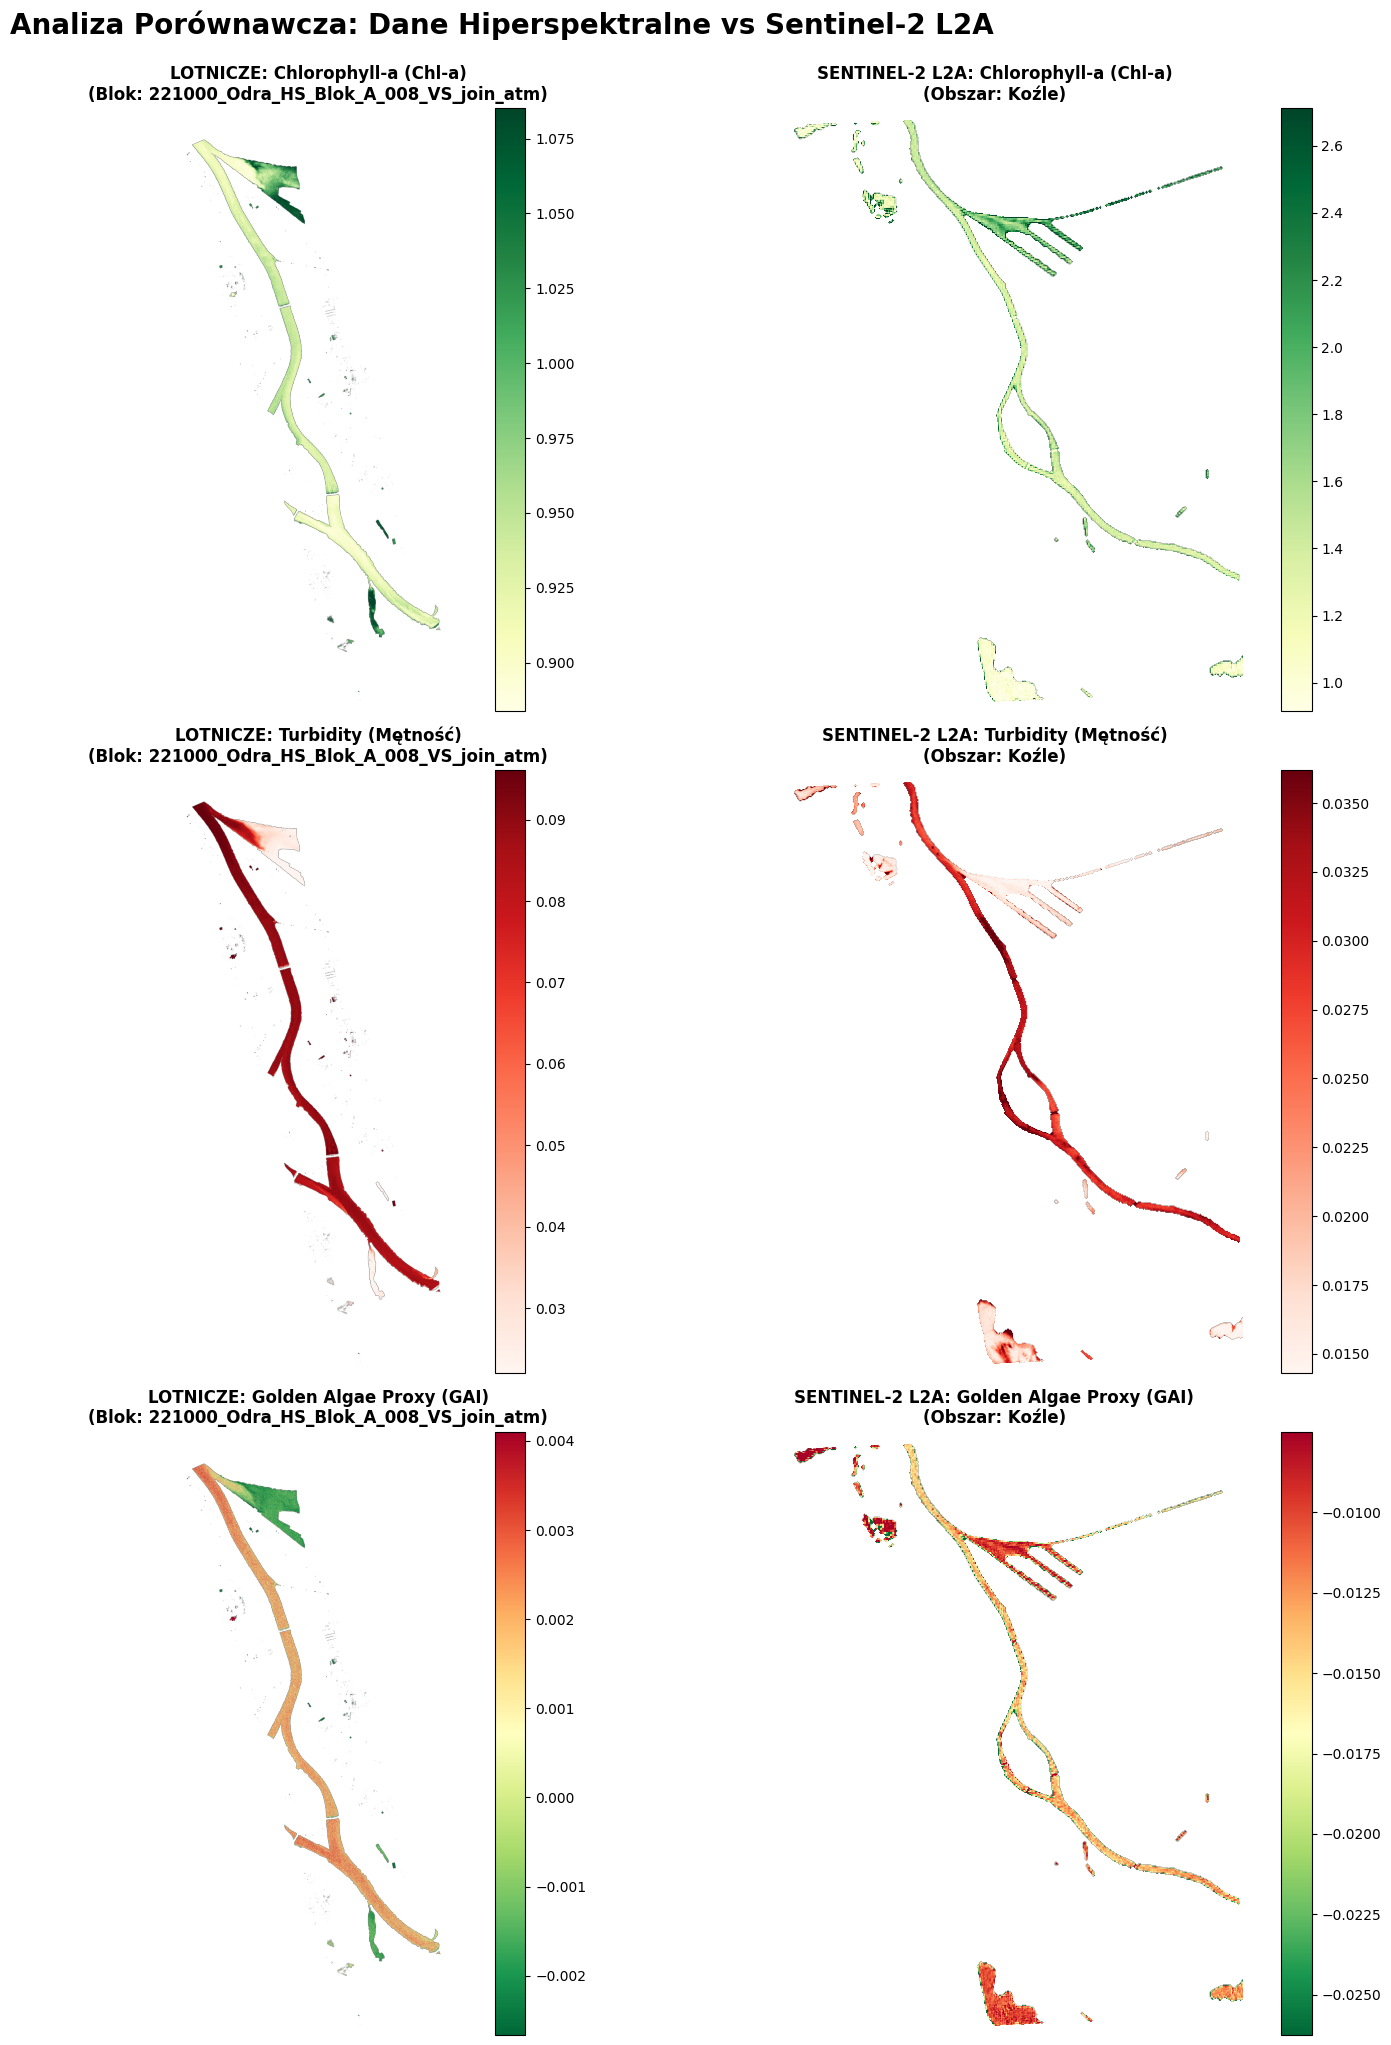

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

block_name = list(all_results.keys())[0]
air_data = all_results[block_name]

comparison_map = [
    (air_data['Chl-a'], s2_chl_a_final, "Chlorophyll-a (Chl-a)", "YlGn"),
    (air_data['Turbidity'], s2_turb_final, "Turbidity (Mętność)", "Reds"),
    (air_data['GAI'], s2_gai_final, "Golden Algae Proxy (GAI)", "RdYlGn_r")
]

fig, axes = plt.subplots(3, 2, figsize=(18, 20))

for i, (air_val, s2_val, title, cmap) in enumerate(comparison_map):

    v_min_a, v_max_a = np.nanpercentile(air_val, [5, 95])
    im_a = axes[i, 0].imshow(air_val, cmap=cmap, vmin=v_min_a, vmax=v_max_a)
    axes[i, 0].set_title(f"LOTNICZE: {title}\n(Blok: {block_name})", fontweight='bold')
    plt.colorbar(im_a, ax=axes[i, 0], fraction=0.046, pad=0.04)
    axes[i, 0].axis('off')
    

    v_min_s, v_max_s = np.nanpercentile(s2_val, [5, 95])
    im_s = axes[i, 1].imshow(s2_val, cmap=cmap, vmin=v_min_s, vmax=v_max_s)
    axes[i, 1].set_title(f"SENTINEL-2 L2A: {title}\n(Obszar: Koźle)", fontweight='bold')
    plt.colorbar(im_s, ax=axes[i, 1], fraction=0.046, pad=0.04)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.suptitle(f"Analiza Porównawcza: Dane Hiperspektralne vs Sentinel-2 L2A", fontsize=20, y=1.02, fontweight='bold')
plt.show()